## Exercise 8
In primo luogo viene implementato il calcolo del valore atteso dell’Hamiltoniana a partire da una funzione d’onda di prova:

$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

Si ha quindi che:
$$
E_{loc}(x) = \frac{\hat{H}\Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)} = \frac{\left( -\frac{1}{2}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi_T(x)}{\Psi_T(x)} = -\frac{1}{2} \frac{\frac{\partial^2}{\partial x^2}\Psi_T(x)}{\Psi_T(x)} + V(x)
$$
La derivata seconda viene calcolata analiticamente:
$$
\frac{\partial^2 \Psi_T}{\partial x^2} = \left( \frac{(x - \mu)^2}{\sigma^4} - \frac{1}{\sigma^2} \right) e^{-\frac{(x-\mu)^2}{2\sigma^2}} + \left( \frac{(x + \mu)^2}{\sigma^4} - \frac{1}{\sigma^2} \right) e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

In altre parole, si implementa il calcolo della seguente espressione:
$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$
dove
$$
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2}
$$
corrisponde alla distribuzione di probabilità target. Per campionare tale distribuzione tramite Metropolis si utilizza la probabilità di accettazione $p(x)=\min(1,q)$, dove $q$ è definito come:
$$
q =  \int \frac{|\Psi_T(x_{new})|^2}{|\Psi_T(x_{old})|^2} 
$$

L’obiettivo dell’esercizio è minimizzare $\langle \hat{H} \rangle_T$, cosa che viene ottenuta tramite l’algoritmo di Simulated Annealing. Si ottengono le seguenti grafiche, che mostrano il processo di ottimizzazione e i risultati finali:

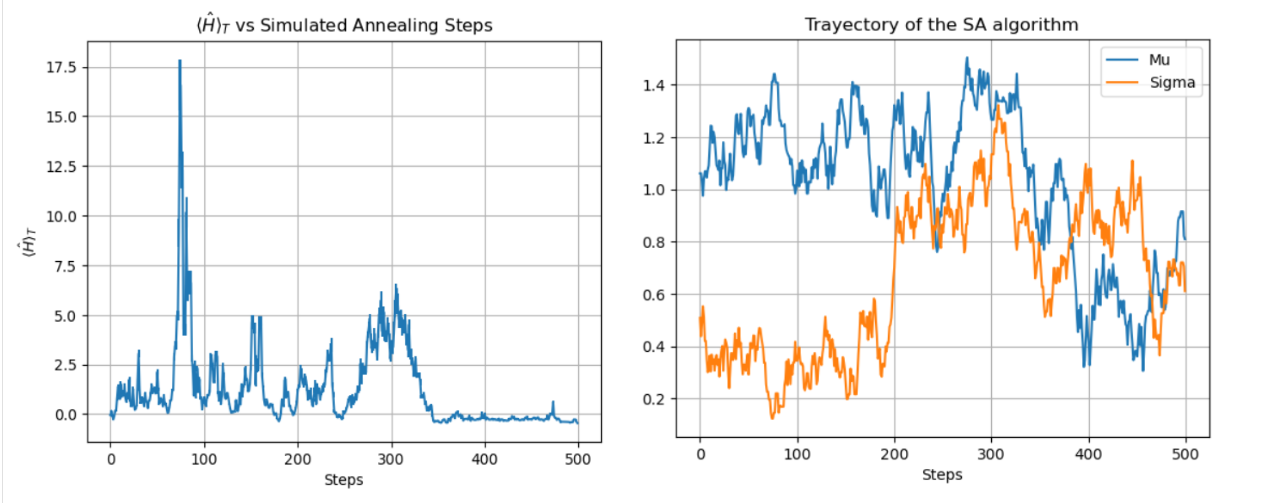

Si osserva che nel Simulated Annealing inizialmente sono presenti fluttuazioni di energia dovute all’alta temperatura; man mano che questa diminuisce, i parametri $\mu$ e $\sigma$ si stabilizzano fino a raggiungere i valori ottimali.

Si osservano picchi verso l’alto, nonostante il processo di minimizzazione, dovuti al fattore di probabilità del *Simulated Annealing*:
$$P = \begin{cases} 
e^{-\frac{\Delta E}{T_{SA}}} & \text{if } \Delta E > 0 \\ 
1 & \text{if } \Delta E < 0 
\end{cases}$$

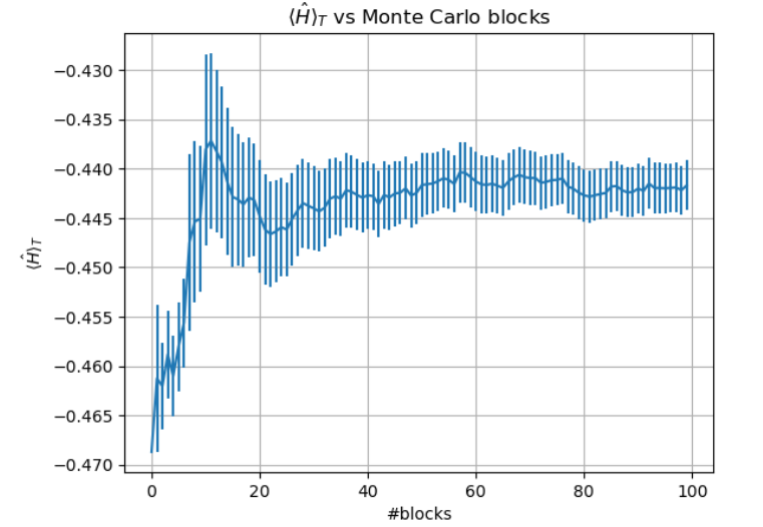

Con i parametri ottimali trovati si osserva una rapida stabilizzazione di $\langle \hat{H} \rangle_T$: le fluttuazioni diminuiscono progressivamente fino a convergere attorno al valore circa $-0.442$.

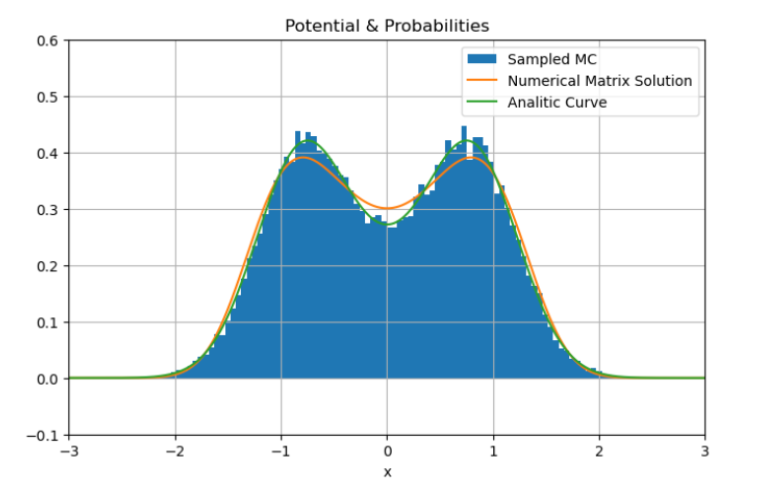

Infine, il grafico mostra una distribuzione con due minimi di potenziale, con una buona sovrapposizione tra l’istogramma (ottenuto tramite Metropolis) e la curva analitica, validando l’implementazione del sampling. Inoltre entrambe le curve risultano in buon accordo con la soluzione numerica matriciale fornita nel materiale supplementare.

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt

def error(ave,ave2,n):  # Function for statistical uncertainty estimation
    if n==0:
        return 0
    else:
        return math.sqrt((ave2[n] - ave[n]**2)/n)

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2
   
def fonda(x, mu, sigma):     # Wave proof function
    return math.exp(-(x-mu)**2/(2*sigma**2)) + math.exp(-(x+mu)**2/(2*sigma**2))

def E_loc(x, mu, sigma):
    f_pos = math.exp(-(x+mu)**2/(2*sigma**2))
    f_neg = math.exp(-(x-mu)**2/(2*sigma**2))

    d2 = ((x-mu)**2/sigma**4-1/sigma**2)*f_neg + ((x+mu)**2/sigma**4-1/sigma**2)*f_pos
    return -1/2*d2/fonda(x, mu, sigma) + Vpot(x)

def energia_MC(mu, sigma, total=False, M=10000, N=20):
    L=int(M/N)            # Number of throws in each block
    ave = np.zeros(N)
    av2 = np.zeros(N)
    sum_prog = np.zeros(N)
    su2_prog = np.zeros(N)
    err_prog = np.zeros(N)
    
    x = 0.0               # Initial particle position
    dx = 1.9              # Adjusted to the aceptation
    accepted = 0          # Counter for the aceptation rate

    x_total = []        # Counter for the histogram
    
    for i in range(N):
        sumE = 0
        for j in range(L):
            x_new = x + np.random.uniform(-dx, dx)  # Aleatory step
            q = (fonda(x_new, mu, sigma) / fonda(x, mu, sigma))**2  
            if np.random.rand() < min(1, q):    # Step accepted
                x = x_new     
                accepted +=1
            if total:     
                x_total.append(x)
            sumE += E_loc(x, mu, sigma)
        ave[i] = sumE / L
        av2[i] = (ave[i])**2       
    
    for i in range(N):
        for j in range(i+1):
            sum_prog[i] += ave[j] # SUM_{j=0,i} r_j
            su2_prog[i] += av2[j] # SUM_{j=0,i} (r_j)^2
        sum_prog[i]/=(i+1) # Cumulative average
        su2_prog[i]/=(i+1) # Cumulative square average
        err_prog[i] = error(sum_prog,su2_prog,i) # Statistical uncertainty
        
    # Returns final energy, statistical uncertainty and acceptation rate
    if total:
        print(f"Acceptation rate: {(accepted / M) * 100:.1f}%")
        return sum_prog, err_prog, x_total
    else:
        return sum_prog[-1], err_prog[-1]


# SIMULATED ANNELING

np.random.seed(1)     # Fixing random seed for reproducibility
# System initials parameters
mu = 1.0
dmu = 0.1
sigma = 0.5
dsigma = 0.1
      
T = 5.0                # Simulated Anneling temperature
dT = 0.01
times = int(T/dT)
# Initial energy
E, err = energia_MC(mu, sigma)

SA_E = np.zeros(times)
SA_err = np.zeros(times)
SA_mu = np.zeros(times)
SA_sigma = np.zeros(times)

for step in range(times):
    mu_new = abs(mu + np.random.uniform(-dmu,dmu))
    sigma_new = abs(sigma + np.random.uniform(-dsigma,dsigma))
    E_new, err_new = energia_MC(mu_new, sigma_new)
    dE = E_new - E
    prob = math.exp(-dE/T)
    if dE<0 or np.random.rand()<prob:
        E = E_new
        err = err_new
        mu = mu_new
        sigma = sigma_new
    SA_err[step] = err
    SA_E[step] = E
    SA_mu[step] = mu
    SA_sigma[step] = sigma
    T -= dT

# Minimum values
sum_prog, err_prog, x_total = energia_MC(mu, sigma, total=True, M=100000, N=100)


t=np.arange(times)
n=np.arange(len(sum_prog))

#Plot of H as function of the SA steps of the algorithm.
plt.figure()
plt.errorbar(t, SA_E, yerr=SA_err)
plt.title(r"$\langle {\hat H} \rangle_T$ vs Simulated Annealing Steps")
plt.xlabel('Steps')
plt.ylabel(r'$\langle {\hat H} \rangle_T$')
plt.grid(True)
plt.show()        


#Plot of trajectory of the SA algorithm in the variational parameter space as a function of the SA steps.
plt.figure()
plt.plot(t, SA_mu, label='Mu')
plt.plot(t, SA_sigma, label='Sigma')
plt.title(r"Trayectory of the SA algorithm")
plt.xlabel('Steps')
plt.legend()
plt.grid(True)
plt.show()

#Plot of estimated H as a function of the MC blocks when H is minimized
plt.figure()
plt.errorbar(n, sum_prog, yerr=err_prog)
plt.title(r"$\langle {\hat H} \rangle_T$ vs Monte Carlo blocks")
plt.xlabel('#blocks')
plt.ylabel(r'$\langle {\hat H} \rangle_T$')
plt.grid(True)
plt.show() 



# Histogram with the sampled configurations compared with its analytic curve and
# with the numerical solution.
hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

# Analitic Curve
psi_analitic = np.array([fonda(i, mu, sigma)**2 for i in x]) 
psi_analitic /= np.trapezoid(psi_analitic, x)  # to normalize

plt.figure(figsize=(8,5))
scale = 0.3
plt.hist(x_total, bins=100, density=True, label='Sampled MC')  
plt.plot(x,(psi[0])**2, label='Numerical Matrix Solution')                
plt.plot(x, psi_analitic, label='Analitic Curve')
plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.legend()
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.1,0.6))
plt.show()